### **[Monte Carlo Simulation on Stock Price Forecasting](https://medium.com/@simonleung5jobs/7010e79a8b53)**

**Monte Carlo Simulation** is a sophisticated computational technique that employs iterative random sampling based on predefined probability distributions (e.g., normal, uniform) to generate numerical outcomes. This method constructs models of potential results by substituting a spectrum of values — represented by a probability distribution — for any variable exhibiting inherent uncertainty. The simulation then performs repeated calculations, utilizing a distinct set of random values from the probability functions in each iteration.

In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import yfinance as yf

import plotly.io as pio
import plotly.express as px
import plotly.graph_objects as go

import scipy.stats as stats
from scipy.stats import anderson
from scipy.stats import kstest, t

from statsmodels.tsa.stattools import adfuller

from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
np.set_printoptions(precision=6, suppress=True)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', '{:.6f}'.format)

%autosave 10

Autosaving every 10 seconds


In [2]:
def get_stock_data(ticker, start_date, end_date):
  try:
    data = yf.download(ticker, start=start_date, end=end_date, progress=False)

    if isinstance(data.columns, pd.MultiIndex):
      data.columns = data.columns.get_level_values(0)

    return data
  except Exception as e:
    return f"Error fetching data: {e}"

In [3]:
ticker_symbol = "PREIX"  #  T. Rowe Price Equity Index 500 Fund
start_date = "2000-01-01"
end_date = "2024-10-01"
stock_data = get_stock_data(ticker_symbol, start_date, end_date)
stock_data.asfreq('B').index  # set index frequency to business daliy
display(stock_data.head(10))

Price,Close,High,Low,Open,Volume
Date,,,,,
2000-01-03,23.963495,23.963495,23.963495,23.963495,0
2000-01-04,23.046053,23.046053,23.046053,23.046053,0
2000-01-05,23.094992,23.094992,23.094992,23.094992,0
2000-01-06,23.119461,23.119461,23.119461,23.119461,0
2000-01-07,23.749434,23.749434,23.749434,23.749434,0
2000-01-10,24.012424,24.012424,24.012424,24.012424,0
2000-01-11,23.700504,23.700504,23.700504,23.700504,0
2000-01-12,23.596527,23.596527,23.596527,23.596527,0
2000-01-13,23.883987,23.883987,23.883987,23.883987,0


In [4]:
result = adfuller(stock_data['Close'], regression ='ctt')
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
  print('\t%s: %.3f' % (key, value))

if result[1]  > 0.05 :
  print('Fail to reject the null hypothesis (H0), the data has a unit root and is non-stationary.')
elif result[1] <= 0.05 :
  print('Reject the null hypothesis (H0), the data does not have a unit root and is stationary.')

ADF Statistic: -2.587533
p-value: 0.518966
Critical Values:
	1%: -4.373
	5%: -3.833
	10%: -3.554
Fail to reject the null hypothesis (H0), the data has a unit root and is non-stationary.


In [5]:
# calculate the daily returns of the stock investment based on the percentage of the close price changes.
# The pct_change method will automatically calculate the percentage changes of the current day’s close price compared with the previous day.
stock_data['Daily_Return'] = stock_data['Close'].pct_change()
stock_data.dropna(inplace=True)
display(stock_data.head(10))

Price,Close,High,Low,Open,Volume,Daily_Return
Date,,,,,,
2000-01-04,23.046053,23.046053,23.046053,23.046053,0,-0.038285
2000-01-05,23.094992,23.094992,23.094992,23.094992,0,0.002124
2000-01-06,23.119461,23.119461,23.119461,23.119461,0,0.001060
2000-01-07,23.749434,23.749434,23.749434,23.749434,0,0.027249
2000-01-10,24.012424,24.012424,24.012424,24.012424,0,0.011074
2000-01-11,23.700504,23.700504,23.700504,23.700504,0,-0.012990
2000-01-12,23.596527,23.596527,23.596527,23.596527,0,-0.004387
2000-01-13,23.883987,23.883987,23.883987,23.883987,0,0.012182
2000-01-14,24.134758,24.134758,24.134758,24.134758,0,0.010500


In [6]:
# Perform Anderson-Darling test
result = anderson(stock_data['Daily_Return'], dist='norm')
print(f'Statistic: {result.statistic:.4f}')

for i in range(len(result.critical_values)):
    sl, cv = result.significance_level[i], result.critical_values[i]
    print('Significance Level: %.3f, Critical Value: %.3f' % (sl, cv))
    if result.statistic < cv:
        print('Sample looks normal (fail to reject H0)')
    else:
        print('Sample does not look normal (reject H0)')

Statistic: 115.5564
Significance Level: 15.000, Critical Value: 0.576
Sample does not look normal (reject H0)
Significance Level: 10.000, Critical Value: 0.656
Sample does not look normal (reject H0)
Significance Level: 5.000, Critical Value: 0.786
Sample does not look normal (reject H0)
Significance Level: 2.500, Critical Value: 0.917
Sample does not look normal (reject H0)
Significance Level: 1.000, Critical Value: 1.091
Sample does not look normal (reject H0)


In [7]:
# Fit the data using t-distribution
params = t.fit(stock_data['Daily_Return'])
d, p_value = kstest(stock_data['Daily_Return'], 't', args=params)
print(f"KS Statistic: {d}, P-Value: {p_value}")

if p_value > 0.05:
    print('Sample fits the t-distribution (fail to reject H0)')
else:
    print('Sample does not fit the t-distribution (reject H0)')

KS Statistic: 0.0172017823707004, P-Value: 0.049696184058099835
Sample does not fit the t-distribution (reject H0)


Degrees of Freedom: 2.6654037752161526, Mean: 0.0007116627411420318, Standard Deviation: 0.007115769615332399


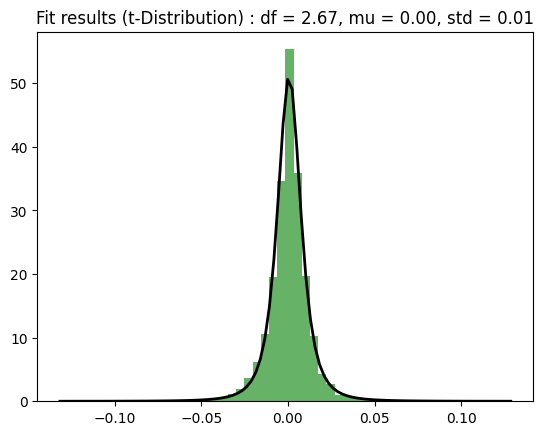

In [8]:
# Fit a t-distribution to the daily return data
params = t.fit(stock_data['Daily_Return'])

# Get the parameters
dfree, mu, std = params
print(f"Degrees of Freedom: {dfree}, Mean: {mu}, Standard Deviation: {std}")

# Plot the histogram and the PDF
plt.hist(stock_data['Daily_Return'], bins=50, density=True, alpha=0.6, color='g')

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = t.pdf(x, dfree, mu, std)

plt.plot(x, p, 'k', linewidth=2)
title = f"Fit results (t-Distribution) : df = {dfree:.2f}, mu = {mu:.2f}, std = {std:.2f}"
plt.title(title)

plt.show()

if not IN_COLAB:
  # Save the figure
  plt.savefig('t_dist.jpg', dpi=200)

In [9]:
# Fit a t-distribution to the daily return data
params = stats.t.fit(stock_data['Daily_Return'])
df_t, loc, scale = params[0], params[1], params[2]

# Number of simulations and forecast days
num_simulations = 1000
forecast_days = 252  # 1 year of trading days

# Generate random samples using t-distribution
simulated_returns = stats.t.rvs(df_t, loc=loc, scale=scale, size=(forecast_days, num_simulations))

# Starting stock price
start_price = stock_data['Close'].iloc[-1]

# Simulate stock price paths
price_paths = np.zeros_like(simulated_returns)
price_paths[0] = start_price

for t in range(1, forecast_days):
    price_paths[t] = np.maximum(price_paths[t - 1] * (1 + simulated_returns[t]), 0)

# Calculate the 5th and 95th percentiles of the stock prices
lower_bound = np.percentile(price_paths, 5, axis=1)
upper_bound = np.percentile(price_paths, 95, axis=1)

# Create a figure
fig = go.Figure()

# Add traces for each simulation
for i in range(num_simulations):
    fig.add_trace(go.Scatter(y=price_paths[:, i], mode='lines', line=dict(color='grey', width=1), showlegend=False))

# Add traces for the lower and upper bounds
fig.add_trace(go.Scatter(y=lower_bound, mode='lines', name='5th Percentile', line=dict(color='red', width=2, dash='dash')))
fig.add_trace(go.Scatter(y=upper_bound, mode='lines', name='95th Percentile', line=dict(color='blue', width=2, dash='dash')))

# Update layout
fig.update_layout(title='Monte Carlo Simulation of Stock Prices with 90% Confidence Interval',
                   xaxis_title='Days',
                   yaxis_title='Stock Close Price $', width=1000, height=600)

# Show the figure
fig.show()

# Save the figure as a JPG image
if not IN_COLAB:
  fig.write_image("MonteCarloSim.jpg")